In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

from src.config import DotDict
from src.data_loader import build_dataloaders

# --- 1. Path Configuration ---
data_root = Path("/media/maro/Mom0-0/Datasets/TCGA/pathological")
project_dir = Path.cwd().resolve().parent.parent.parent

# --- 2. Model Definition ---
class GoogLeNetWSI(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.cnn = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)
        self.cnn.fc = nn.Identity()
        self.head = nn.Sequential(nn.Dropout(dropout_rate), nn.Linear(1024, 1))

    def forward(self, image):
        B, N, C, H, W = image.shape
        x = image.view(B * N, C, H, W)
        features = self.cnn(x).view(B, N, -1)
        return self.head(features.mean(dim=1)).squeeze(-1)

# --- 3. Dataloader Configuration ---
cfg = DotDict({
    "dataset": {
        "data_root": data_root,
        "manifest_tsv": data_root / "raw" /"gdc_sample_sheet.2026-05-10.tsv",
        "images_dir": data_root/ "raw",
        "target_col": "TMB",
        "patient_id_col": "PATIENT_ID",
        "use_preextracted": False,
        "patch_size": 256,
        "image_size": 224,
        "max_patches": 16,
        "val_ratio": 0.15,
        "seed": 42,
        "batch_size": 2
    },
    "modalities": {
        "tabular": False,
        "image": True
    }
})

# Load Data and Frozen Weights


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Building WSI Dataloaders... (This will read SVS files)")
train_loader, val_loader = build_dataloaders(cfg)

# Initialize model
model = GoogLeNetWSI(dropout_rate=0.0)

# Path to your image-only Phase 2 weights
# Update the filename below to match your actual WSI model checkpoint
wsi_weights_path = (
    project_dir
    / "freezed-models"
    / "runs"
    / "checkpoints"
    / "best_wsi_model.pth"
)

print(f"Loading weights from {wsi_weights_path}...")
state_dict = torch.load(wsi_weights_path, map_location=device, weights_only=False)
cleaned_state_dict = {k.replace('_est.', ''): v for k, v in state_dict.items()}
model.load_state_dict(cleaned_state_dict)

model.to(device)
model.eval() # Ensure Dropout/BatchNorm are frozen
print("WSI Model Ready for XAI.")

Building WSI Dataloaders... (This will read SVS files)
Loading weights from /home/maro/final-projects/DSAI_305_XAI/freezed-models/runs/checkpoints/best_wsi_model.pth...
WSI Model Ready for XAI.


# Define the Grad-CAM Hook Class


In [3]:
class PatchGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        # Register PyTorch hooks
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_heatmap(self, image_tensor, target_patch_idx=0):
        self.model.zero_grad()

        # Forward pass
        pred = self.model(image_tensor)

        # Backward pass (calculate gradients of the prediction)
        pred[0].backward(retain_graph=True)

        # Extract gradients and activations for the SPECIFIC patch
        # Activations/Gradients shape: [Batch*Patches, Channels, H, W]
        patch_grads = self.gradients[target_patch_idx]
        patch_acts = self.activations[target_patch_idx]

        # 1. Global Average Pooling of the gradients (Alpha weights)
        weights = torch.mean(patch_grads, dim=(1, 2), keepdim=True)

        # 2. Multiply activations by weights
        cam = torch.sum(weights * patch_acts, dim=0)

        # 3. Apply ReLU (we only care about positive influences on TMB)
        cam = F.relu(cam)

        # 4. Normalize between 0 and 1
        cam = cam - torch.min(cam)
        cam = cam / (torch.max(cam) + 1e-8)

        return cam.cpu().numpy()

# Hook into the final Inception block before pooling
target_layer = model.cnn.inception5b
grad_cam = PatchGradCAM(model, target_layer)

# Run Grad-CAM on a Sample Patient

Cannot open WSI /media/maro/Mom0-0/Datasets/TCGA/pathological/raw/d22eb4ac-7a25-4c23-8f3d-f5851fa77309/TCGA-VQ-A91A-01Z-00-DX1.B0F3EE79-4246-4534-9763-EB9C6D60F3AA.svs: Unsupported or missing image file
Patient TCGA-VQ-A91A: no modality data found — sample will be empty.
Cannot open WSI /media/maro/Mom0-0/Datasets/TCGA/pathological/raw/b4610dce-ba36-4d83-9e3d-0a4391876cad/TCGA-HU-A4GC-01Z-00-DX1.A4B077E3-E5D0-4120-9C72-87BDACF9AC14.svs: Unsupported or missing image file
Patient TCGA-HU-A4GC: no modality data found — sample will be empty.
Cannot open WSI /media/maro/Mom0-0/Datasets/TCGA/pathological/raw/79d8a385-b517-420b-95f2-5add6c63cd34/TCGA-RD-A7C1-01Z-00-DX1.217B7632-39AC-41E1-8491-20C700B08AEC.svs: Unsupported or missing image file
Patient TCGA-RD-A7C1: no modality data found — sample will be empty.
Cannot open WSI /media/maro/Mom0-0/Datasets/TCGA/pathological/raw/d073856b-c6cb-4d09-880f-c8e1dd85b999/TCGA-D7-A6EY-01Z-00-DX1.7E101F3B-8923-4554-AA48-C2493D0F46C0.svs: Unsupported or 

['TCGA-BR-4256', 'TCGA-B7-5816']
Successfully loaded WSI for Patient: TCGA-B7-5816


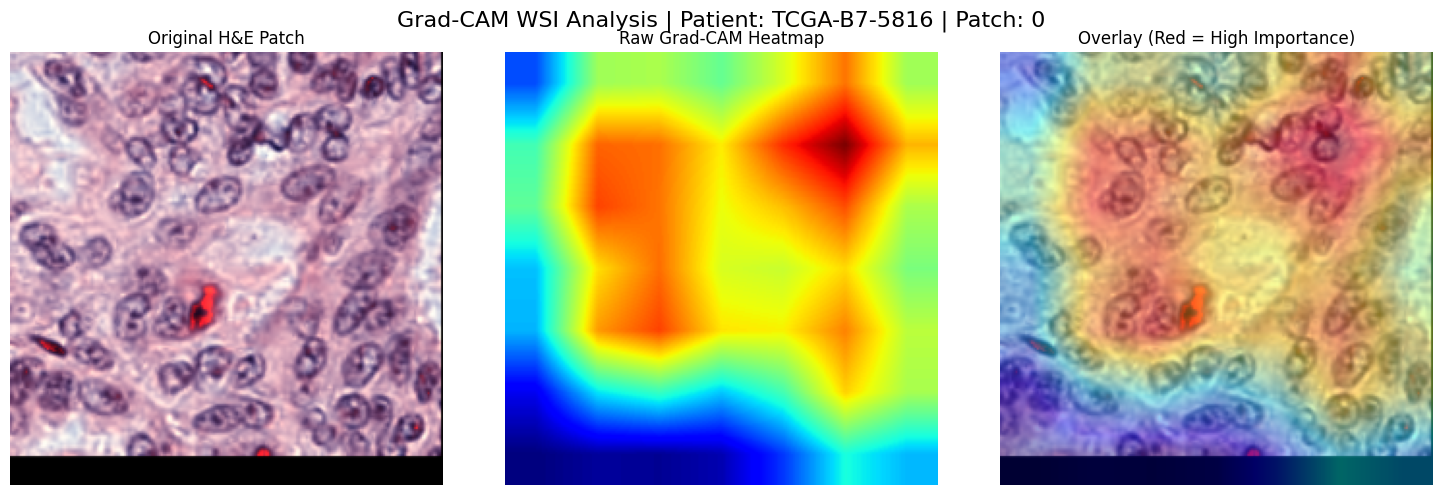

In [5]:
# Cell 4: Execute Grad-CAM and Visualize
val_iterator = iter(val_loader)

# Safely hunt for a patient that has valid image data
val_batch = None
for batch in val_iterator:
    if batch["image"] is not None:
        val_batch = batch
        break

if val_batch is None:
    raise ValueError("Could not find any patients with valid SVS images in the validation set!")

print(val_batch["patient_ids"])
images = torch.tensor(val_batch["image"], dtype=torch.float32).to(device) # Shape: [1, 16, 3, 224, 224]
patient_id = val_batch["patient_ids"][1]

print(f"Successfully loaded WSI for Patient: {patient_id}")

# Choose which patch to visualize (0 to 15)
PATCH_IDX = 0

# Generate Heatmap
heatmap = grad_cam.generate_heatmap(images, target_patch_idx=PATCH_IDX)

# --- Reverse ImageNet Normalization for Display ---
mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3)
std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3)

raw_img = images[0, PATCH_IDX].cpu().numpy().transpose(1, 2, 0)
disp_img = (raw_img * std) + mean
disp_img = np.clip(disp_img, 0, 1)

# --- Resize Heatmap & Apply Colormap ---
heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
heatmap_colored = np.float32(heatmap_colored) / 255
heatmap_colored = heatmap_colored[..., ::-1] # BGR to RGB

# Blend image and heatmap
overlay = 0.6 * disp_img + 0.4 * heatmap_colored
overlay = np.clip(overlay, 0, 1)

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Grad-CAM WSI Analysis | Patient: {patient_id} | Patch: {PATCH_IDX}", fontsize=16)

axes[0].imshow(disp_img)
axes[0].set_title("Original H&E Patch")
axes[0].axis('off')

axes[1].imshow(heatmap_resized, cmap='jet')
axes[1].set_title("Raw Grad-CAM Heatmap")
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title("Overlay (Red = High Importance)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

> The Grad-CAM overlay successfully validates the visual branch of the architecture. The network's regions of maximum activation (red) perfectly colocalize with areas of high nuclear density and structural atypia (enlarged, irregular nuclei). By anchoring its attention on these specific cellular abnormalities—and ignoring benign stromal regions—the model proves it has learned a direct mapping between aberrant cellular morphology (phenotype) and Tumor Mutational Burden (genotype).